```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

# Comparing Entropy Measures
Empirical analysis

In [1]:
# If these are not available (e.g., colab), please uncomment the lines below.
# ! pip install pooch

import pooch

In [2]:
# DATASET TERMS OF SERVICE NOTICE
# The dataset used below is available at: https://doi.org/10.7910/DVN/0SGZFF
# It is downloaded here purely for convenience, as this specific analysis
# complies with its Terms of Service (ToS). For any other usage, or if you
# modify this notebook, you MUST visit the official link to review and accept
# the ToS. By executing this code, you acknowledge that you have read and
# accepted the dataset's Terms of Service.

survey_and_browser_attrs_fpath = pooch.retrieve(
    url='doi:10.7910/DVN/0SGZFF/survey-and-browser-attributes-data.csv',
    known_hash="md5:8f6db8be6551cc740c9a64d6c2bc8a8f"
)

## Browser attributes data
We replace NaN values with the empty string so that these are handled similarly and so that NaN values are captured by calls to value_counts.


We only include browser attributes we consider stable for fingerprinting.

In [3]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# view all the columns
pd.set_option('display.max_columns', None)

stable_ba_names = [
    'User agent', 'Languages', # Can be collected passively via HTTP headers
    'Timezone', 'Screen resolution',
    'Color depth', 'Platform', 'Touch points',
    'Hardware concurrency', 'Device memory',
    'WebGL Vendor', 'WebGL Unmasked Vendor',
    'WebGL Renderer', 'WebGL Unmasked Renderer',
]
# Replace nan values with the empty string
sba_df = pd.read_csv(
    survey_and_browser_attrs_fpath, usecols=['ResponseId']+stable_ba_names
).set_index('ResponseId').fillna('')
N = len(sba_df)
N

8400

In [4]:
import hashlib

def get_unhashed_fingerprint(user_data):
  return ':'.join(pd.Series(user_data).values.astype(str).tolist())

def get_fingerprint(user_data):
  return hash(get_unhashed_fingerprint(user_data))

sba_df['Fingerprint'] = sba_df[stable_ba_names].apply(get_fingerprint, axis=1)

## Metrics to compare

- Shannon entropy: H(X) = -∑ Pr[X = x] log Pr[X = x]
- Normalized Shannon entropy: $\frac{H(X)}{H_N}$
- Tsallis entropy (complement of REID score): T(X) = 1 - ∑ Pr[X = x]^2
- Unicity (fraction unique)

Where $H_N = log_2(N)$ representing worst case.

Higher values mean larger fingerprint identification risk

In [5]:
from scipy.stats import entropy
# shannon entropy (standard measurement)


def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  H = entropy(pk, base=2) # unit is bits
  return H

def get_normalized_shannon_entropy(values):
  """Returns value H(X)/H_N where H_N represents worst case where all values are unique."""
  H_N = get_shannon_entropy(list(range(len(values))))
  return get_shannon_entropy(values)/H_N

def get_reid_score(values):
  pk = values.value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  return pk.pow(2).sum()

def get_tsallis_entropy(values):
  return 1 - get_reid_score(values)

def get_frac_unique(values):
  value_counts = values.value_counts()
  return round((value_counts == 1).sum()/len(values), 4)


test_attr = 'User agent'
values = sba_df[test_attr]
print('%0.3f = Shannon entropy for %s' % (get_shannon_entropy(values), test_attr))
print('%0.3f = Normalized Shannon entropy for %s' % (get_normalized_shannon_entropy(values), test_attr))

4.613 = Shannon entropy for User agent
0.354 = Normalized Shannon entropy for User agent


Table: For each attribute include:

Attribute, Distinct values, Unicity, Shannon entropy, Normalized Shannon entropy, Tsallis entropy, Example (most common) value

The cell below generates the data for **Table 2** of the paper: *Browser attributes and fingerprinting measures (N=8400).*

In [6]:
attributes = stable_ba_names + ['Fingerprint']
df = pd.DataFrame({
    'Attribute': attributes,
    'Distinct values': [sba_df[a].nunique() for a in attributes],
    '% Unique': [round(100*(sba_df[a].value_counts() == 1).sum()/N, 1) for a in attributes],
    'Shannon entropy': [round(get_shannon_entropy(sba_df[a]),3) for a in attributes],
    'Norm. entropy': [round(get_normalized_shannon_entropy(sba_df[a]),3) for a in attributes],
    'Tsallis entropy': [round(get_tsallis_entropy(sba_df[a]),3) for a in attributes],
    'Example value (most frequent)': [sba_df[a].mode()[0] for a in attributes],
})
df.set_index('Attribute')
# display(df.style.hide(axis='index'))

,Distinct values,% Unique,Shannon entropy,Norm. entropy,Tsallis entropy,Example value (most frequent)
Attribute,,,,,,
User agent,434,2.8,4.613,0.354,0.859,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
Languages,264,2.4,1.730,0.133,0.484,"en-US,en"
Timezone,49,0.2,2.064,0.158,0.674,America/New_York
Screen resolution,572,4.5,5.510,0.423,0.940,"[1920,1080]"
Color depth,3,0.0,0.616,0.047,0.204,24
Platform,12,0.0,2.114,0.162,0.688,Win32
Touch points,11,0.0,1.463,0.112,0.581,0
Hardware concurrency,24,0.1,2.340,0.180,0.727,4.0
Device memory,7,0.0,1.611,0.124,0.610,8.0


## Plot histograms and entropy for each attribute


For each attribute plot:
- histogram
- log histogram
- scaling plots:
  - Shannon entropy
  - Normalized Shannon entropy
  - Tsallis entropy
  - Relative errors

Use consistent colors, lines for each entropy measure.


In [7]:
# Histograms
def plot_distribution(df, attribute_name, ax=None, ylabel=False, title=None, logscale=True, dpi=100, color='black'):
  if ax is None:
    fig, ax = plt.subplots(1,1,figsize=(2.5,1.5), dpi=dpi)
  value_counts = df[attribute_name].value_counts()
  value_counts.index = value_counts.index.astype(str)
  ax.bar(value_counts.index, value_counts.values, log=logscale, color=color)
  if title: ax.set_title(title)
  if ylabel:
    ax.set_ylabel('Users')# (N=%s)'%(len(df)))
  ax.set_xlabel('Values (%s distinct)' % len(value_counts))
  ax.set_xticks([])
  return ax

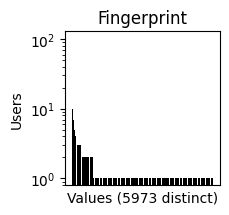

In [8]:
fig, ax = plt.subplots(1,1,figsize=(2,2), dpi=100)
ax = plot_distribution(sba_df, 'Fingerprint', ylabel=True, ax=ax, title='Fingerprint')

To what extent are these metrics dependent on scale (number of users) or data distribution?

We use the following plots to inform this:

Sample size vs scale
- X-axis: sample size (N)
- Y-axis Shannon entropy, Normalized Shannon entropy, Tsallis entropy

The plots are created by repeated random subsampling of the data (without replacement). For each n in {200, 400, ...8400} we compute the metrics. Repeated random sampling is used for each value of n to compute means.


In [9]:
"""
Produce the data for the scaling plots

Want to end up with a mapping of
Attribute name: Dataframe
Where the dataframe has columns:
n, shannon entropy mean, normalized entropy mean, tsallis entropy mean
"""

RANDOM_STATE = 0
TRIALS = 100

ns = [i for i in range(200, 8400+1, 200)]


def get_random_subsample(df, n, trial=0):
  """Returns random subsample of size n."""
  return df.sample(n=n, replace=False, random_state=RANDOM_STATE+trial)


def get_n_resampled_entropy(df=sba_df, attribute_name='Fingerprint', ns=ns, trials=TRIALS):
  """
  Compute entropy for varying n as the mean over repeated random sampling process

  Returns a dataframe with columns for the means for each metric:
  n, Shannon (mean), Norm. Shannon, Tsallis
  """
  attribute_series = df[attribute_name]
  shannon_means = []
  norm_shannon_means = []
  tsallis_means = []
  for i, n in enumerate(ns):
    if (i % 10 == 0): print('%s: %s/%s: n=%s' % (pd.Timestamp.now(), i, len(ns), n))
    shannon = []
    norm_shannon = []
    tsallis = []
    for t in range(trials):
      a_subsampled = get_random_subsample(attribute_series, n, t)
      shannon += [get_shannon_entropy(a_subsampled)]
      norm_shannon += [get_normalized_shannon_entropy(a_subsampled)]
      tsallis += [get_tsallis_entropy(a_subsampled)]
    shannon_means += [np.mean(shannon)]
    norm_shannon_means += [np.mean(norm_shannon)]
    tsallis_means += [np.mean(tsallis)]
  return pd.DataFrame({
      'n': ns,
      'Shannon': shannon_means,
      'Norm Shannon': norm_shannon_means,
      'Tsallis': tsallis_means,
  }).set_index('n')


In [10]:
do_recompute_f_metrics = True # << Flip to True for first run
trials = 100


def get_fname(attribute_name, trials):
  return './%s_mean%s.csv'%(attribute_name, trials)


attributes_entropy_means = {}
# a = 'Fingerprint'
for a in attributes:
  print('Getting fingerprinting metrics for %s' % a)
  fname = get_fname(a, trials)
  if do_recompute_f_metrics:
    print('recomputing metrics with %s trials' % trials)
    attributes_entropy_means[a] = get_n_resampled_entropy(sba_df, a, trials=trials)
    # save to file
    print('saving metrics for %s to %s' % (a, fname))
    attributes_entropy_means[a].to_csv(fname)
  attributes_entropy_means[a] = pd.read_csv(fname, index_col=0)

Getting fingerprinting metrics for User agent
recomputing metrics with 100 trials
2026-03-18 22:33:45.307770: 0/42: n=200
2026-03-18 22:33:50.450000: 10/42: n=2200
2026-03-18 22:33:58.204907: 20/42: n=4200
2026-03-18 22:34:06.191774: 30/42: n=6200
2026-03-18 22:34:16.840179: 40/42: n=8200
saving metrics for User agent to ./User agent_mean100.csv
Getting fingerprinting metrics for Languages
recomputing metrics with 100 trials
2026-03-18 22:34:18.926604: 0/42: n=200
2026-03-18 22:34:24.819391: 10/42: n=2200
2026-03-18 22:34:31.228120: 20/42: n=4200
2026-03-18 22:34:40.085261: 30/42: n=6200
2026-03-18 22:34:50.519059: 40/42: n=8200
saving metrics for Languages to ./Languages_mean100.csv
Getting fingerprinting metrics for Timezone
recomputing metrics with 100 trials
2026-03-18 22:34:52.576682: 0/42: n=200
2026-03-18 22:34:57.433056: 10/42: n=2200
2026-03-18 22:35:04.706825: 20/42: n=4200
2026-03-18 22:35:12.701710: 30/42: n=6200
2026-03-18 22:35:23.471401: 40/42: n=8200
saving metrics for 

In [11]:
print(a)
attributes_entropy_means[a].head()

Fingerprint


,Shannon,Norm Shannon,Tsallis
n,,,
200,7.579217,0.991544,0.994622
400,8.517489,0.985381,0.997078
600,9.058327,0.981526,0.997917
800,9.431107,0.977939,0.998329
1000,9.712905,0.974625,0.998575


In [12]:
entropy_colors = {
    'Shannon': 'black',
    'Norm Shannon': 'black',
    'Tsallis': 'black',
}
entropy_lines = {
    'Shannon': '-',
    'Norm Shannon': ':',
    'Tsallis': '-.',
}
entropy_labels = {
    'Shannon': 'Shannon',
    'Norm Shannon': 'Normalized',
    'Tsallis': 'Tsallis',
}

def plot_entropy_scaling(entropy_means, entropy_type='Shannon', ax=None, dpi=100):
  if ax is None:
    fig, ax = plt.subplots(1,1,figsize=(2.5,2), dpi=dpi)
  ax.plot(a_entropy_means.index, a_entropy_means[entropy_type], entropy_lines[entropy_type], label=entropy_labels[entropy_type], color=entropy_colors[entropy_type])
  ax.set_xlim(0, 8400)
  ax.set_xlabel('n')
  return ax


def get_entropy_relative_error(a_entropy_means, entropy_type):
  return abs(a_entropy_means[entropy_type][N] - a_entropy_means[entropy_type])/a_entropy_means[entropy_type][N]


def plot_entropy_error(entropy_means, legend=False, ax=None, dpi=100):
  if ax is None:
    fig, ax = plt.subplots(1,1,figsize=(2.5,2), dpi=dpi)
  ax.set_xlim(0, 8400)
  ax.set_xlabel('n')
  lns = []
  for entropy_type in entropy_lines.keys():
    lns += ax.plot(a_entropy_means.index,
                    get_entropy_relative_error(a_entropy_means, entropy_type),
                    entropy_lines[entropy_type], label=entropy_labels[entropy_type], color=entropy_colors[entropy_type])
  labs = [l.get_label() for l in lns]
  if legend: plt.legend(lns, labs, loc='upper right', facecolor='white', framealpha=0.65)
  return ax


Make plots with selected attributes
- 2 with relatively low entropy:
  - Platform
  - Hardware concurrency
- 2 with relatively high entropy
  - User agent
  - Screen resolution
- Fingerprint

Rows:
- 1: histograms with consistent y-axies
- 2 - 4: entropies, consistent y-axes for each entropy type
- 5: relative error with consistent y-axes



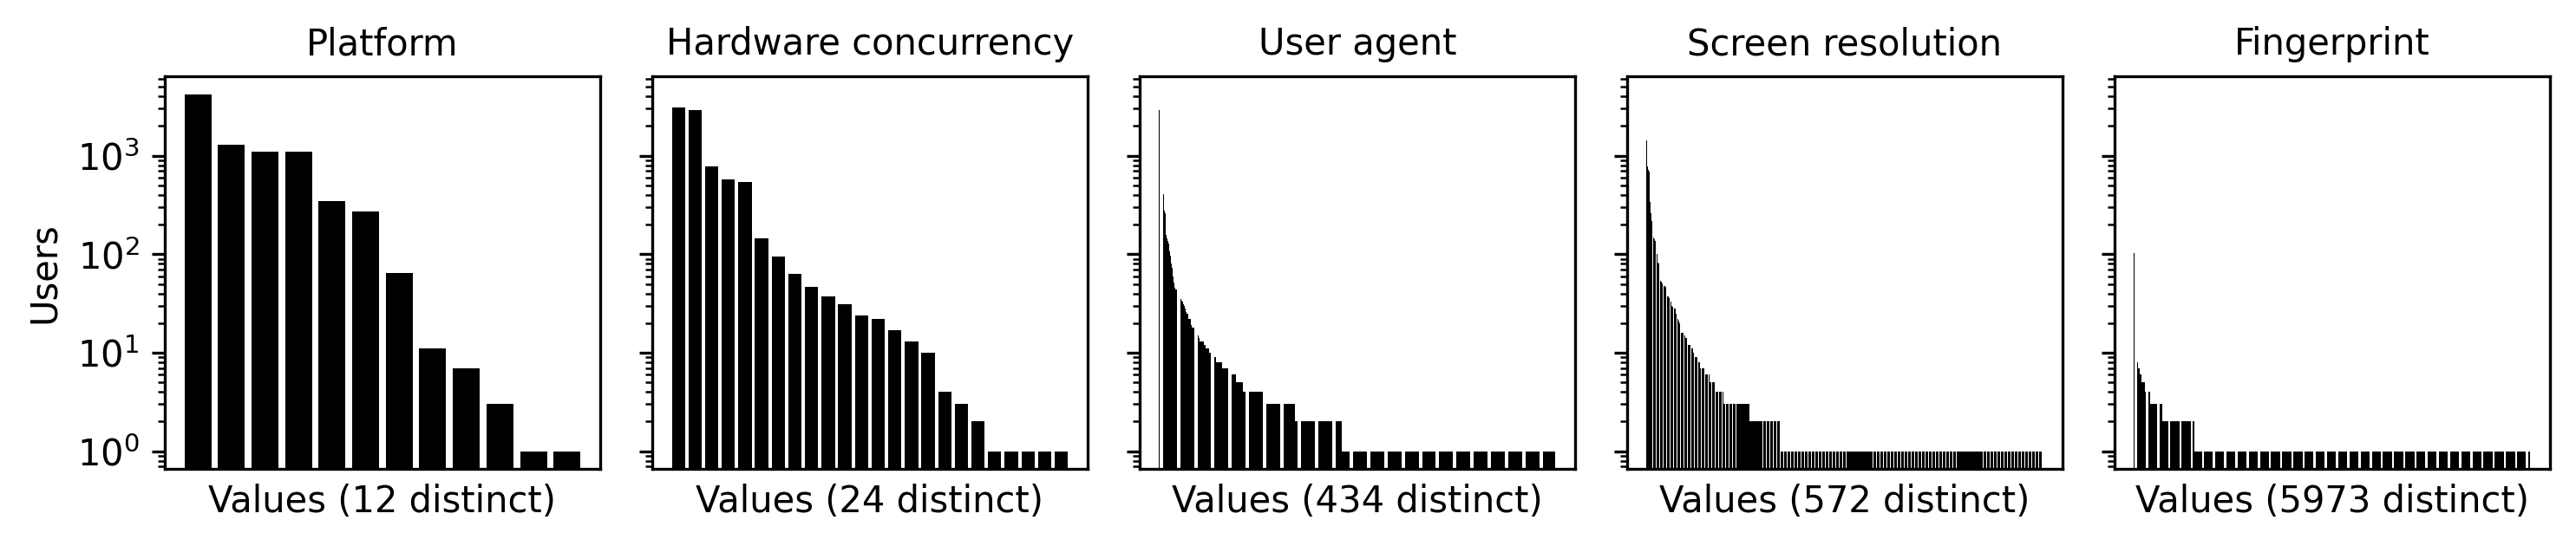

In [13]:
plot_attributes = [
    'Platform',
    'Hardware concurrency',
    'User agent',
    'Screen resolution',
    'Fingerprint'
]

# plot row for histograms
fig, axes = plt.subplots(1, 5, figsize=(10, 2.2), sharey=True, dpi=300)
for i, a in enumerate(plot_attributes):
  ax = plot_distribution(sba_df, a, ylabel=(i==0), ax=axes[i])
  ax.set_title(a, fontdict={'fontsize':10})
plt.tight_layout()


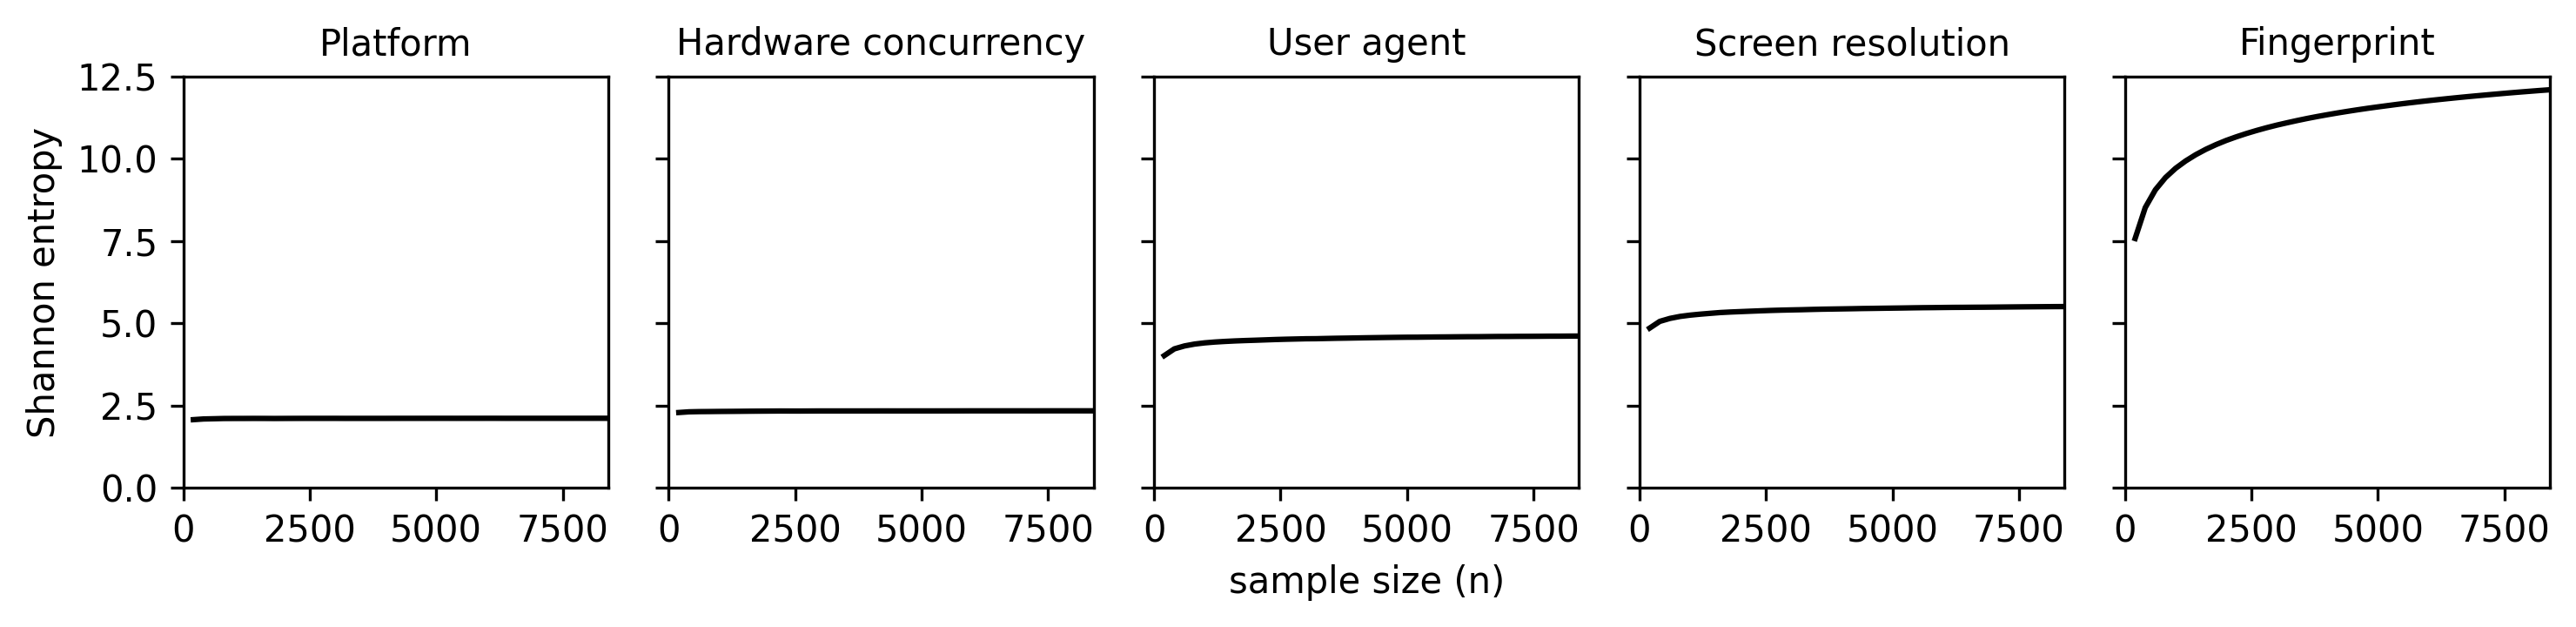

In [14]:
# plot rows for entropies
# Shannon entropy
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5), sharey=True, sharex=True, dpi=300)
for i, a in enumerate(plot_attributes):
  a_entropy_means = attributes_entropy_means[a]
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Shannon', ax=axes[i])
  if i==0: ax.set_ylabel('Shannon entropy')
  ax.set_ylim(0, 12.5)
  ax.set_title(a, fontdict={'fontsize':10})
  ax.set_xticks([0, 2500, 5000, 7500])
  if i == 2: ax.set_xlabel('sample size (n)')
  else: ax.set_xlabel('')
plt.tight_layout()

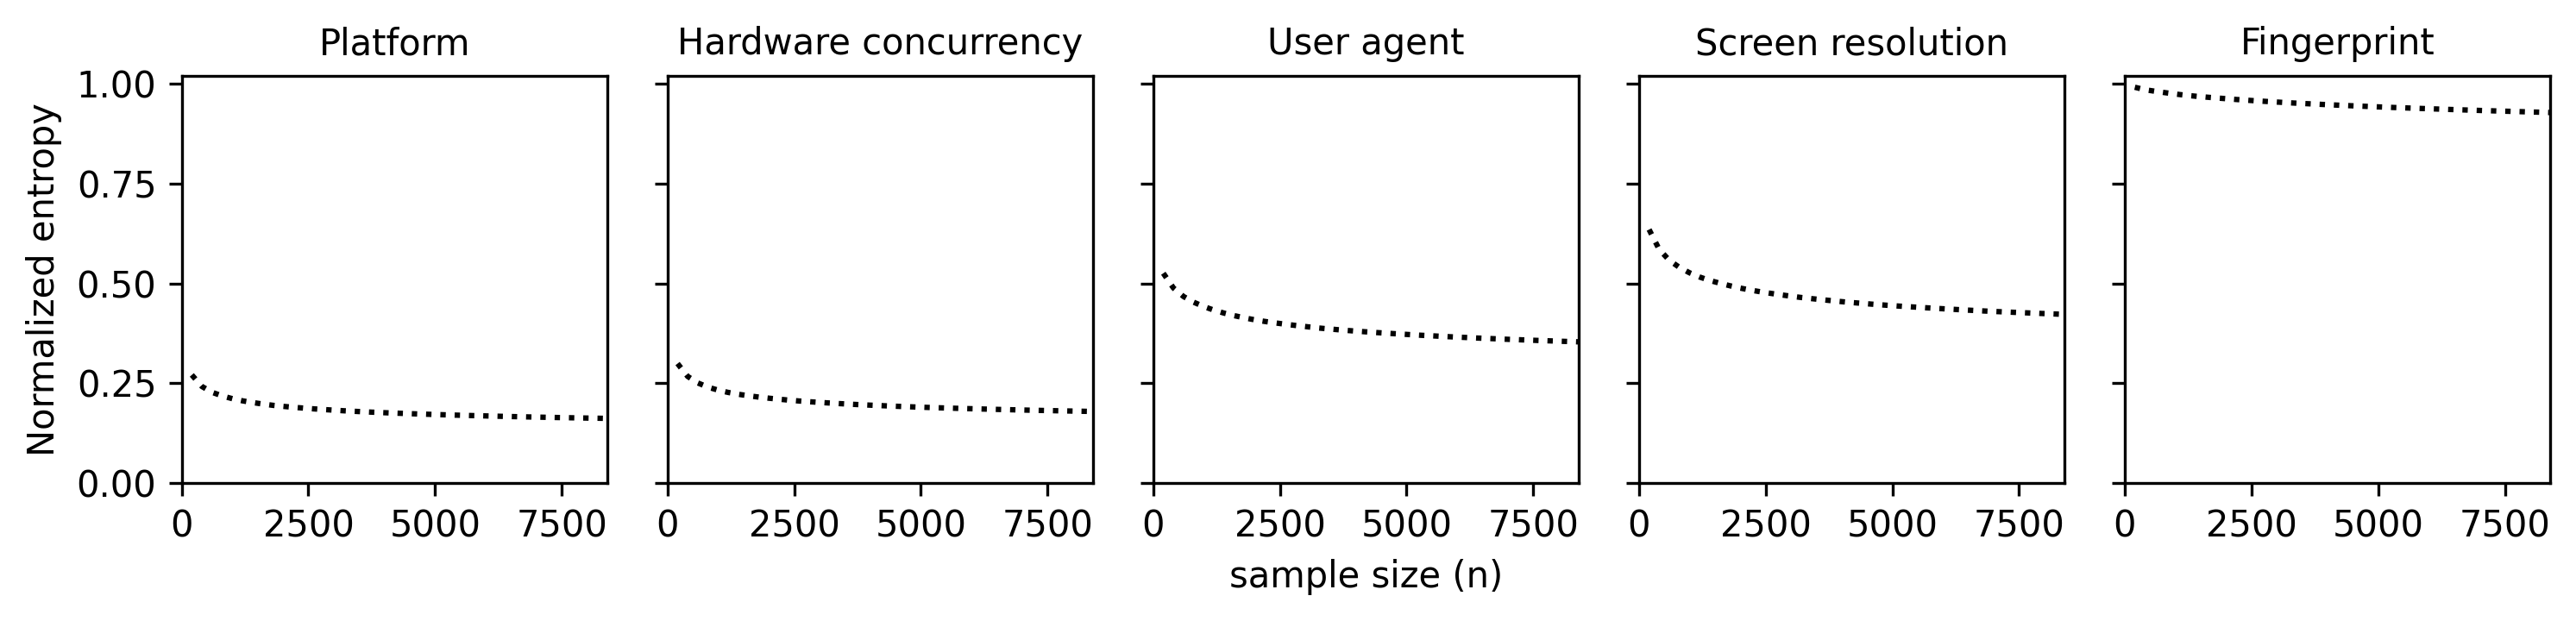

In [15]:
# Normalized entropy
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5), sharey=True, dpi=300)
for i, a in enumerate(plot_attributes):
  a_entropy_means = attributes_entropy_means[a]
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Norm Shannon', ax=axes[i])
  if i==0: ax.set_ylabel('Normalized entropy')
  ax.set_xticks([0, 2500, 5000, 7500])
  ax.set_ylim(0, 1.02)
  if i == 2: ax.set_xlabel('sample size (n)')
  else: ax.set_xlabel('')
  ax.set_title(a, fontdict={'fontsize':10})
plt.tight_layout()

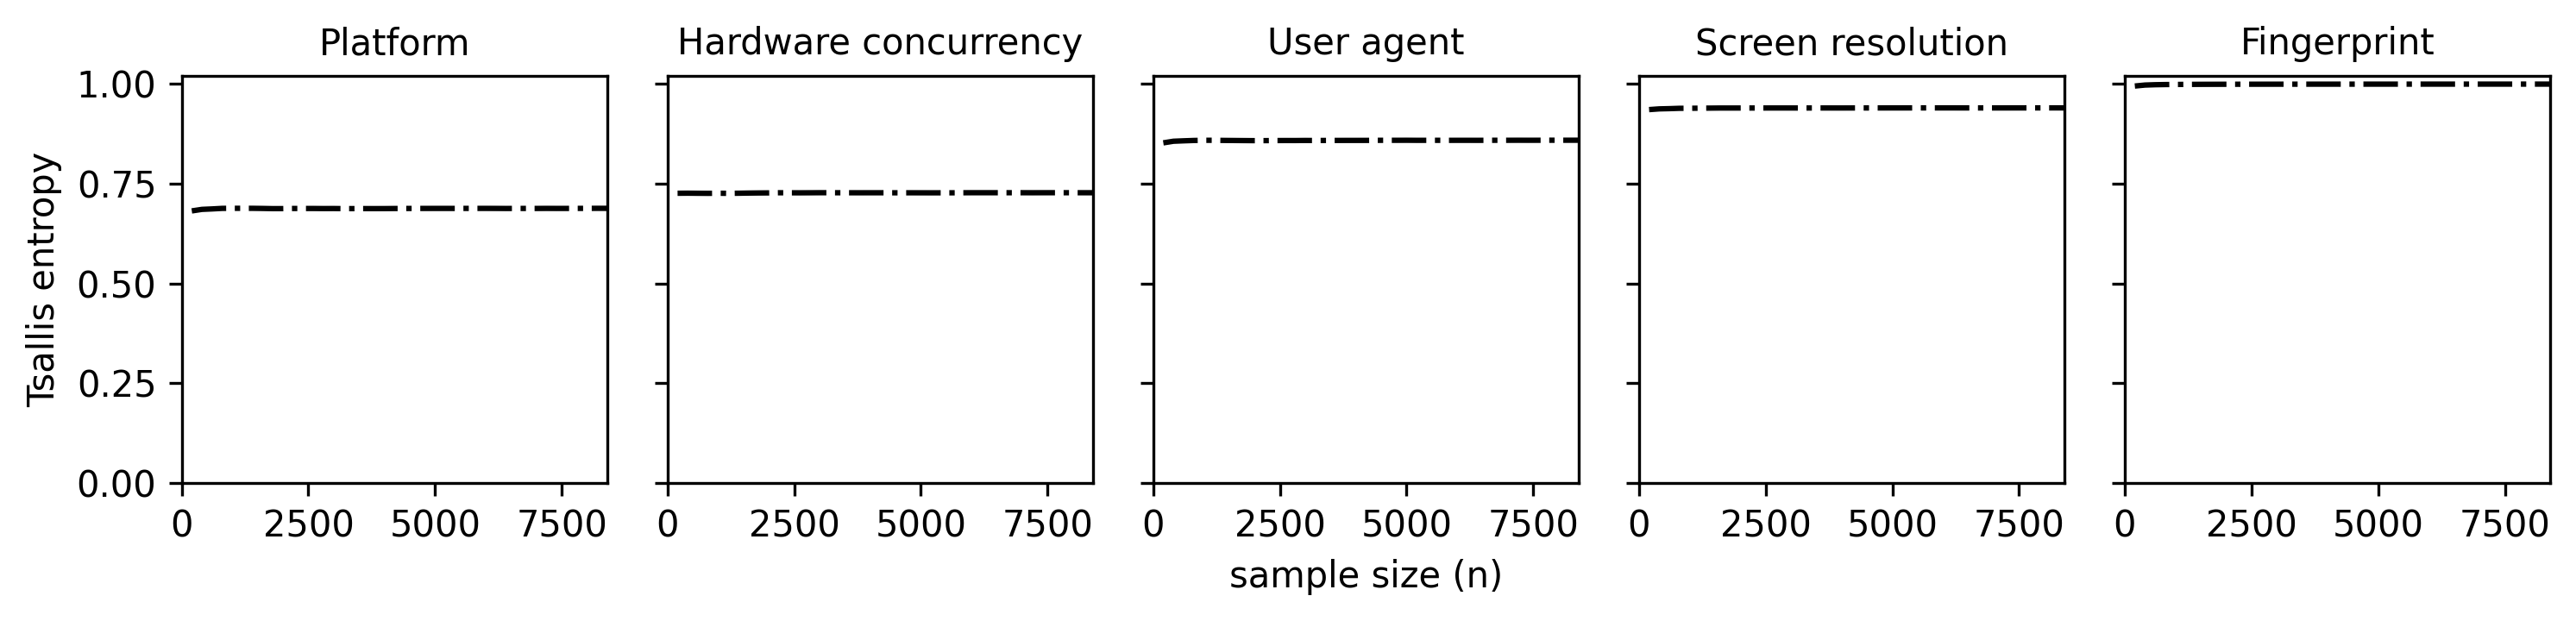

In [16]:
# Tsallis entropy
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5), sharey=True, dpi=300)
for i, a in enumerate(plot_attributes):
  a_entropy_means = attributes_entropy_means[a]
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Tsallis', ax=axes[i])
  if i==0: ax.set_ylabel('Tsallis entropy')
  ax.set_xticks([0, 2500, 5000, 7500])
  ax.set_ylim(0, 1.02)
  if i == 2: ax.set_xlabel('sample size (n)')
  else: ax.set_xlabel('')
  ax.set_title(a, fontdict={'fontsize':10})
plt.tight_layout()

Combined entropy plot

In [17]:
a_entropy_means

,Shannon,Norm Shannon,Tsallis
n,,,
200,7.579217,0.991544,0.994622
400,8.517489,0.985381,0.997078
600,9.058327,0.981526,0.997917
800,9.431107,0.977939,0.998329
1000,9.712905,0.974625,0.998575
1200,9.937779,0.971547,0.998735
1400,10.128458,0.969118,0.998855
1600,10.291929,0.966936,0.998946
1800,10.433773,0.964859,0.999017


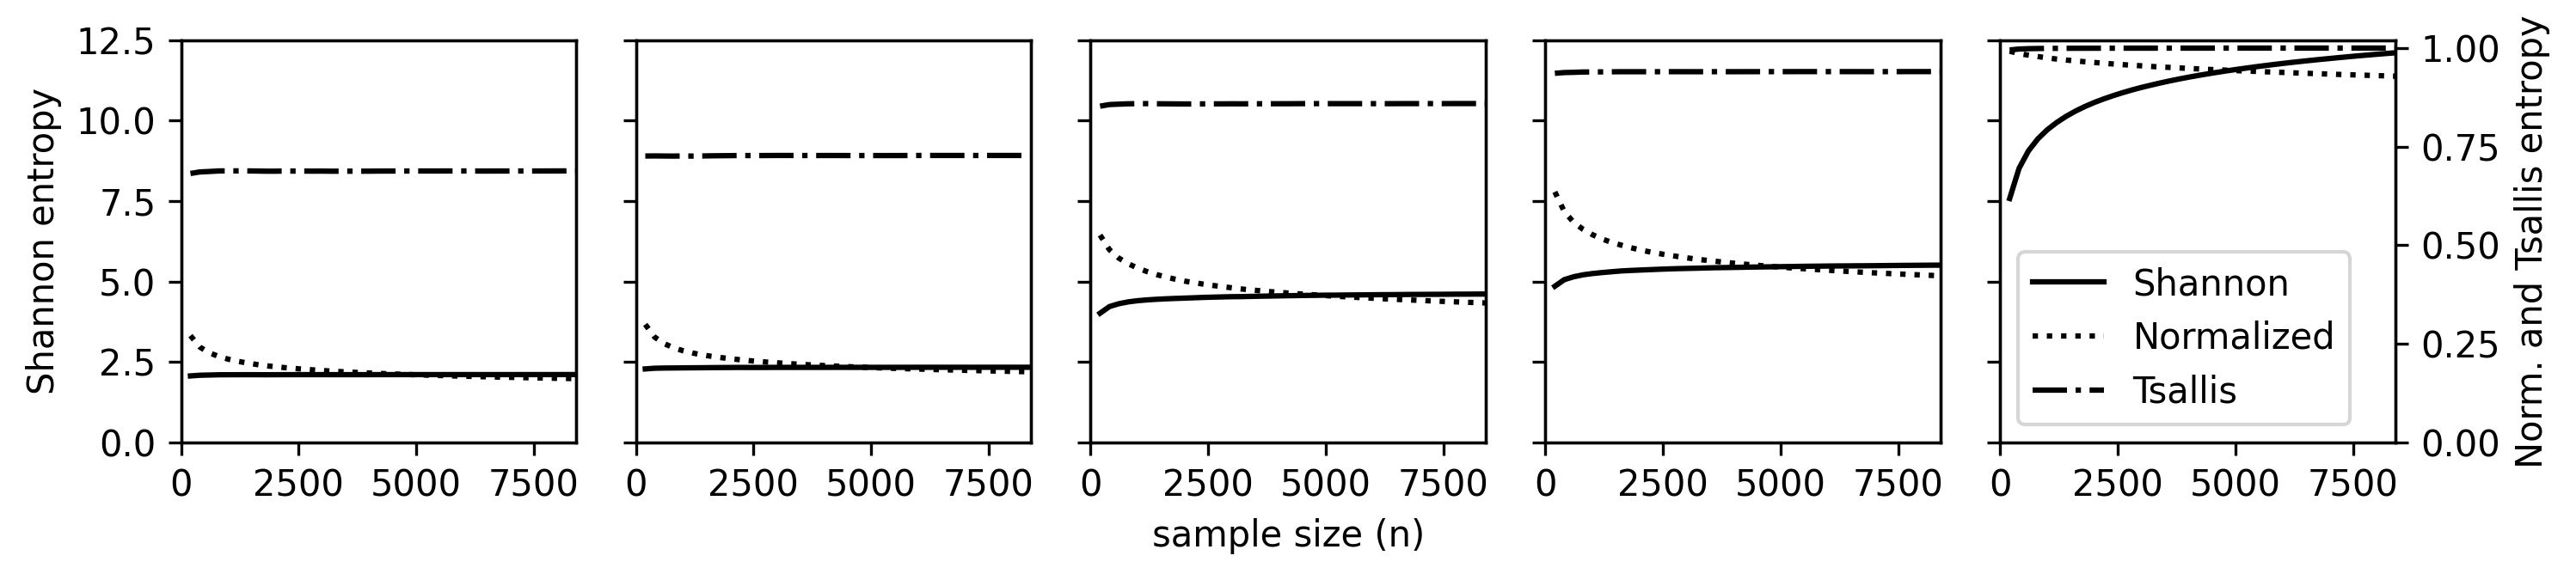

In [18]:
# plot rows for entropies
# Shannon entropy
fig, axes = plt.subplots(1, 5, figsize=(10, 2.35), sharey=True, sharex=True, dpi=300)
for i, a in enumerate(plot_attributes):
  a_entropy_means = attributes_entropy_means[a]
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Shannon', ax=axes[i])
  if i==0: ax.set_ylabel('Shannon entropy')
  ax.set_ylim(0, 12.5)
  #ax.set_title(a, fontdict={'fontsize':10})
  ax.set_xticks([0, 2500, 5000, 7500])
  if i == 2: ax.set_xlabel('sample size (n)')
  else: ax.set_xlabel('')
  ax2 = ax.twinx()
  plot_entropy_scaling(a_entropy_means, entropy_type='Norm Shannon', ax=ax2)
  plot_entropy_scaling(a_entropy_means, entropy_type='Tsallis', ax=ax2)
  ax2.set_ylim(0, 1.02)
  if i==4:
    ax2.set_ylabel('Norm. and Tsallis entropy')
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc=0)
  else: ax2.set_yticks([])

plt.tight_layout()

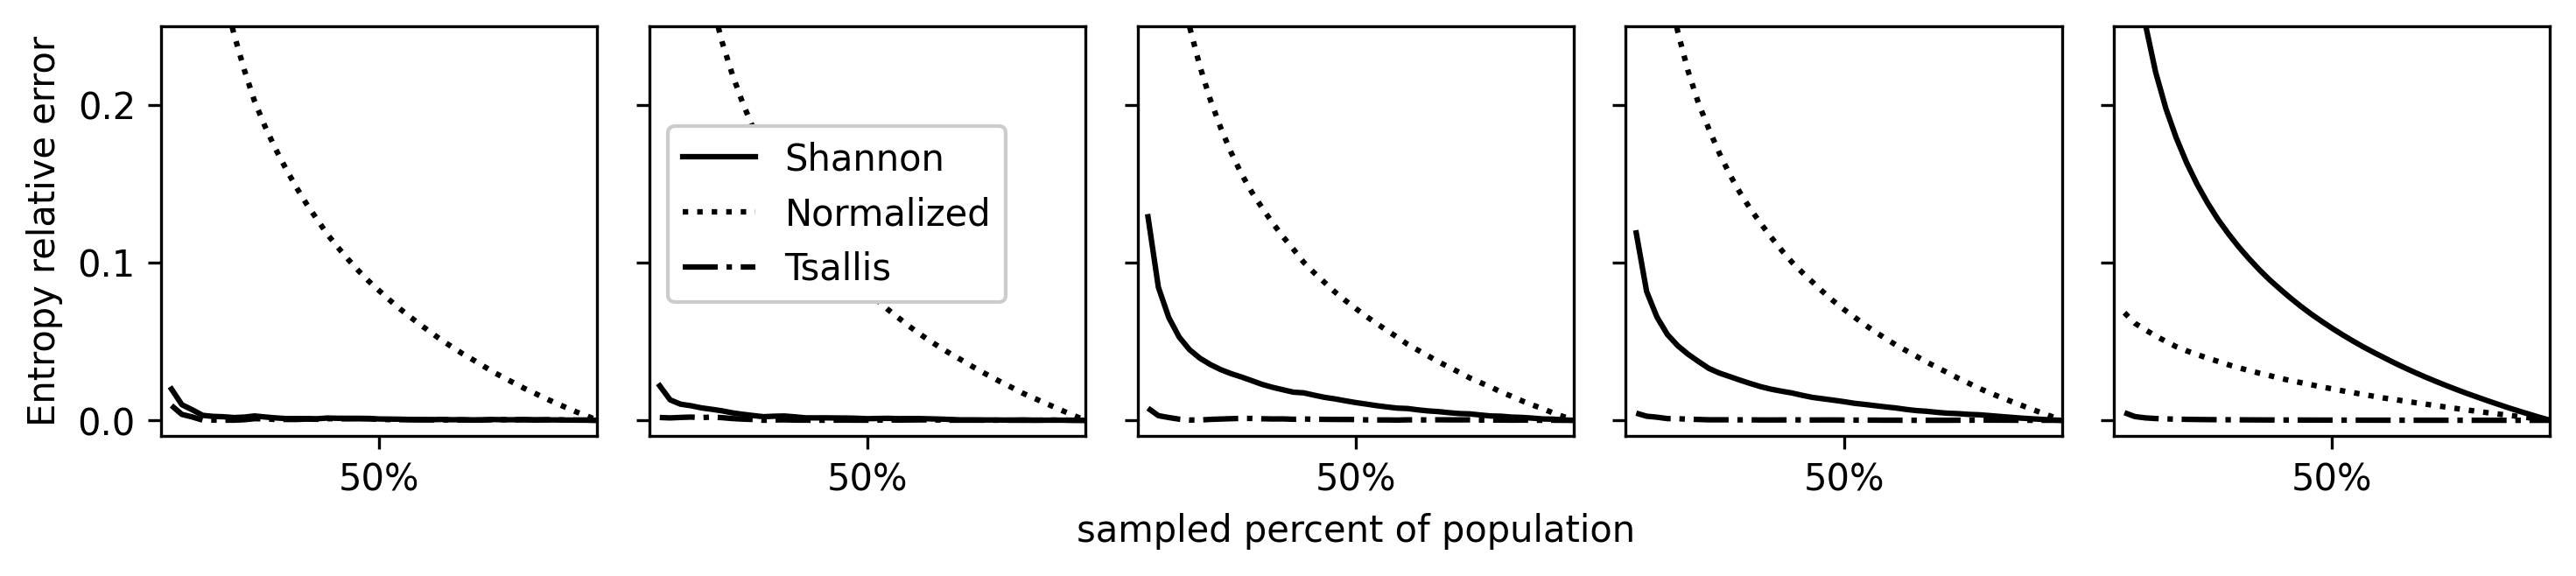

In [19]:
from matplotlib import ticker
# relative error
fig, axes = plt.subplots(1, 5, figsize=(10, 2.35), sharey=True, dpi=300)
for i, a in enumerate(plot_attributes):
  a_entropy_means = attributes_entropy_means[a]
  ax = plot_entropy_error(a_entropy_means, legend=False, ax=axes[i])
  if i==0: ax.set_ylabel('Entropy relative error')
  ax.set_ylim(-0.01, 0.25)
  ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=8400))
  ax.set_xticks([4200])
  # ax.set_xticks([4200, 8400])
  if i == 2: ax.set_xlabel('sampled percent of population')
  else: ax.set_xlabel('')
  #ax.set_title(a, fontdict={'fontsize':10})
plt.tight_layout()
_ = plt.legend(bbox_to_anchor=(-2.5, 0.8), facecolor='white', framealpha=1)

Create plots with all attributes.

Use order consistent with table.

Set up the titles and axes so that the plot can be broken apart across multiple pages.

The cell below generates the plot that is then split into **Figure 5** and **Figure 6** of the paper: *Attribute value distributions and entropy estimates for all attributes shown in Table 1. Left: Histograms show the (logscale) number of users for the given attribute values. Middle: Plots show the mean entropy values estimated over 100 trials for subsamples ranging from n=200 to 8400. Right: The entropy estimate sample error computed as the difference between the mean estimate for the subsample versus population (N=8400). Shannon entropy increases, and normalized entropy decreases, with sample size, especially for attributes with more distinct values, while Tsallis entropy is constant. Estimation error is also lowest for Tsallis entropy.*

0 User agent
1 Languages
2 Timezone
3 Screen resolution
4 Color depth
5 Platform
6 Touch points
7 Hardware concurrency
8 Device memory
9 WebGL Vendor
10 WebGL Unmasked Vendor
11 WebGL Renderer
12 WebGL Unmasked Renderer
13 Fingerprint


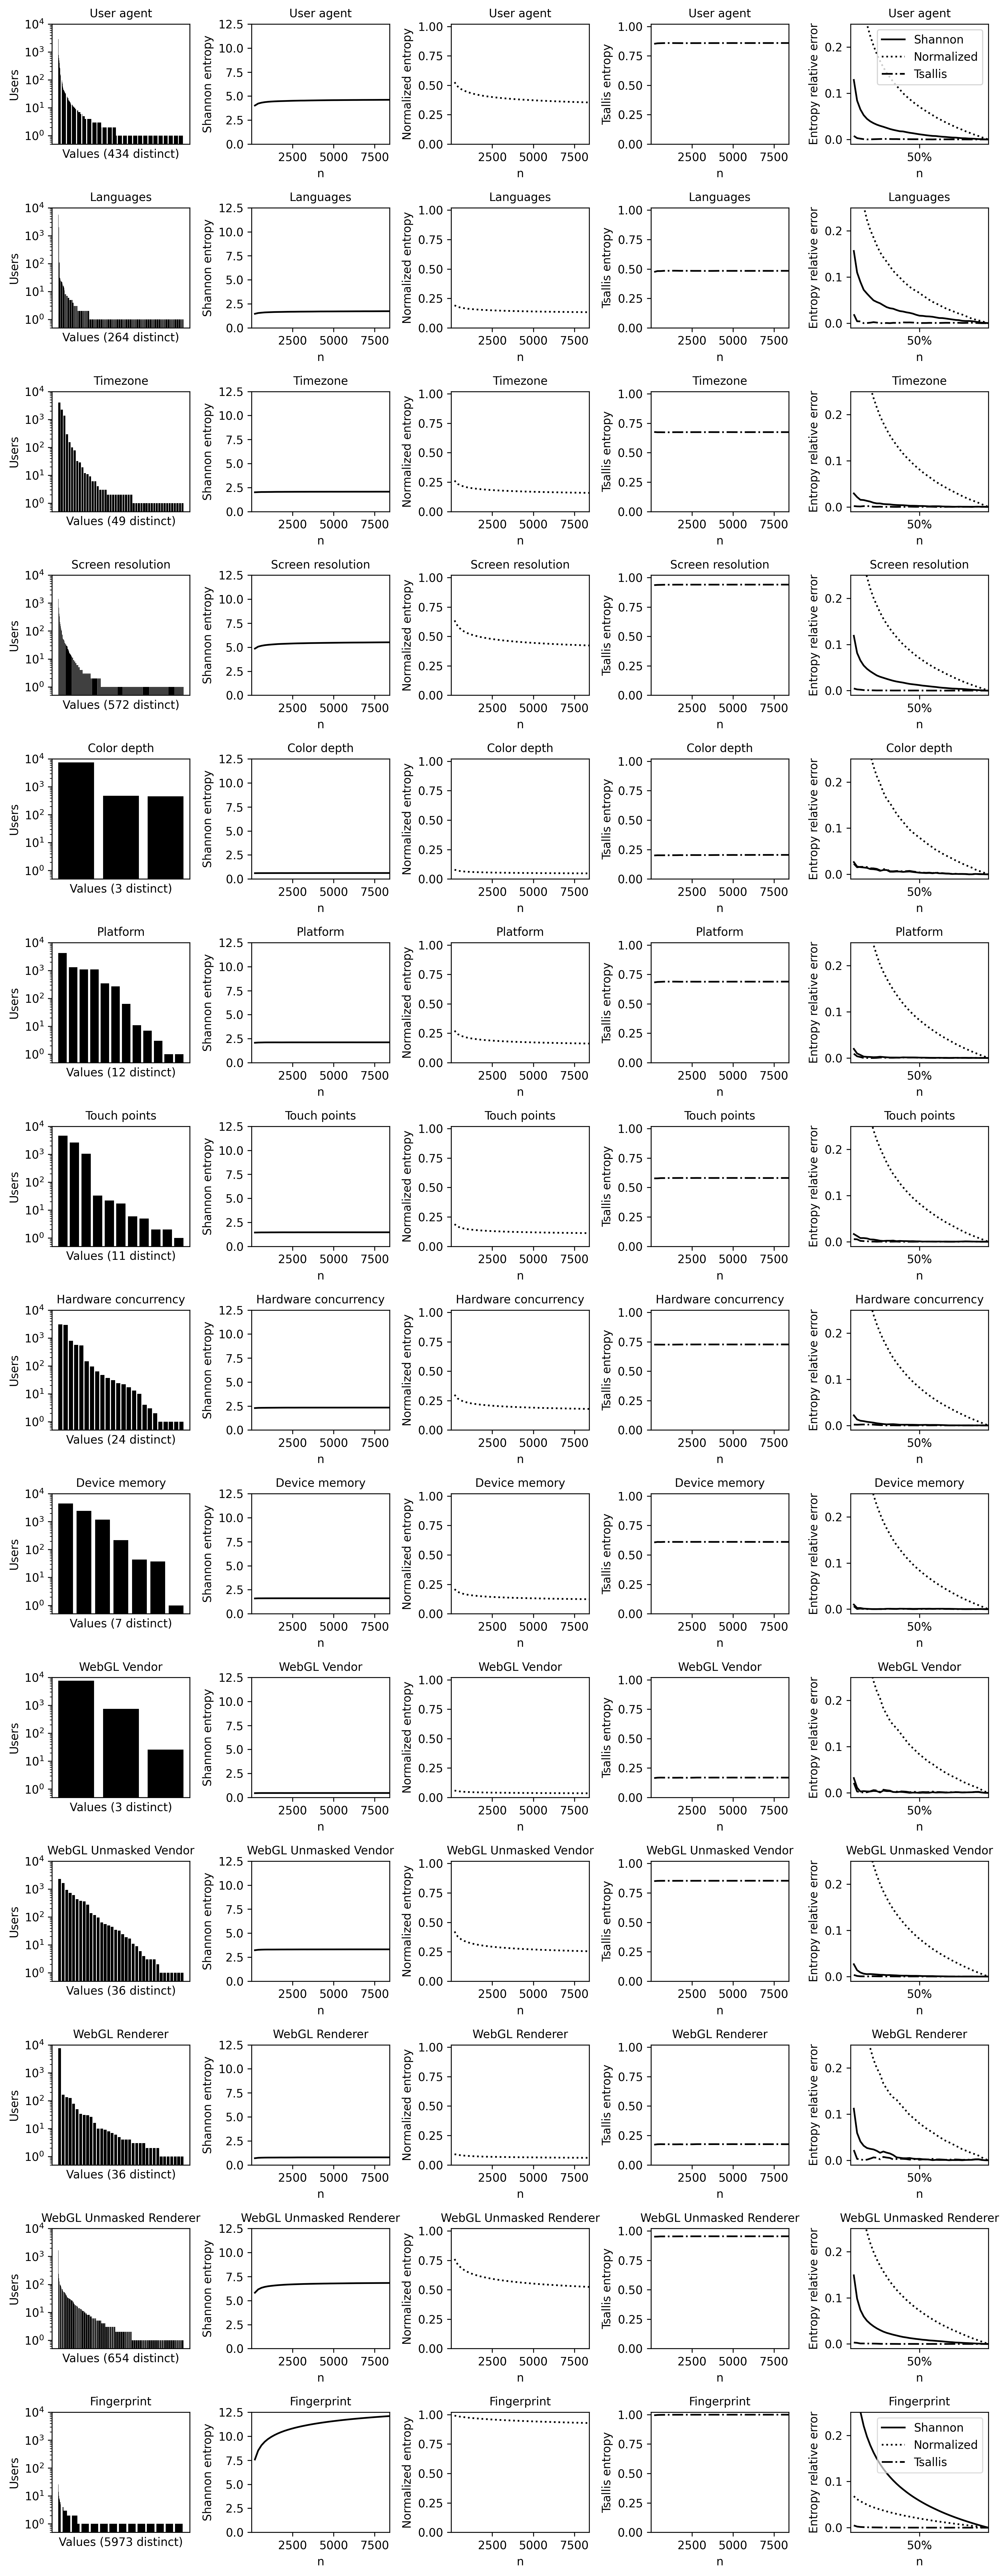

In [20]:
len(attributes) # 14
fig, axes = plt.subplots(len(attributes), 5, figsize=(12.25, 2.25*len(attributes)), dpi=300)
for i, a in enumerate(attributes):
  #if i>3: break
  print(i, a)
  a_entropy_means = attributes_entropy_means[a]
  # one row at a time
  ax = plot_distribution(sba_df, a, ylabel=True, ax=axes[i][0])
  ax.set_ylim(0.5, 10000)
  ax.set_ylabel('Users')
  ax.set_title(a, fontdict={'fontsize':10})
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Shannon', ax=axes[i][1])
  ax.set_ylabel('Shannon entropy')
  ax.set_xticks([2500, 5000, 7500])
  ax.set_ylim(0, 12.5)
  ax.set_title(a, fontdict={'fontsize':10})
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Norm Shannon', ax=axes[i][2])
  ax.set_ylabel('Normalized entropy')
  ax.set_xticks([2500, 5000, 7500])
  ax.set_ylim(0, 1.02)
  ax.set_title(a, fontdict={'fontsize':10})
  ax = plot_entropy_scaling(a_entropy_means, entropy_type='Tsallis', ax=axes[i][3])
  ax.set_ylabel('Tsallis entropy')
  ax.set_ylim(0, 1.02)
  ax.set_xticks([2500, 5000, 7500])
  ax.set_title(a, fontdict={'fontsize':10})
  ax = plot_entropy_error(a_entropy_means, legend=True, ax=axes[i][4])
  ax.set_ylabel('Entropy relative error')
  ax.set_ylim(-0.01, 0.25)
  if i==0: ax.legend()
  ax.set_title(a,fontdict={'fontsize':10})
  ax.set_xticks([4200], ['50%'])
plt.tight_layout()
